**<h1>Tesla and GameStop Stock Analysis</h1>**

<strong>Project Overview : </strong>This project analyzes the relationship between stock prices and company revenue using Tesla (TSLA) and GameStop (GME) data. Data is collected from Yahoo Finance and web-scraped revenue tables, then visualized to identify trends and insights.

<strong>Business Scenario</strong>

This project simulates the role of a Data Analyst working for an investment firm that helps clients evaluate potential stock investments.

To support investment decisions, financial data was collected from multiple sources using Python. Historical stock prices were retrieved through financial APIs, while company revenue data was gathered through web scraping techniques. The collected data was then cleaned, analyzed, and visualized to explore the relationship between company performance and stock market behavior.

This analysis focuses on two well-known companies:

- Tesla (TSLA)
- GameStop (GME)

By comparing stock price movements with revenue trends, the project aims to identify whether changes in company fundamentals are reflected in market valuation.

<strong>Question of Interest</strong>
1. How has Tesla's revenue evolved over time?
2. Does Tesla's stock price growth align with its revenue growth?
3. How has GameStop's revenue changed over the years?
4. Did GameStop's stock price surge correspond to revenue growth?
5. What insights can investors gain by comparing stock prices with company fundamentals?

**<h2>Setup & Libraries</h2>**

In [1]:
!pip install yfinance
!pip install bs4
!pip install nbformat
!pip install matplotlib

In [2]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

**<h2>Define Visualization Function</h2>**

In [3]:
import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

**<h2>Tesla Data Collection & Preparation</h2>**

In [5]:
# Extract Tesla Stock Price Data

tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)
tesla_data.head(5)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [7]:
# Webscraping to Extract Tesla Revenue Data

html_data = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
data  = requests.get(html_data).text
soup = BeautifulSoup(data, 'html.parser')

tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

tbody = soup.find_all("tbody")[1]
for row in tbody.find_all("tr"):
    col = row.find_all("td")
    date = col[0].text
    revenue = col[1].text
    tesla_revenue = pd.concat([tesla_revenue, pd.DataFrame({"Date": [date], "Revenue": [revenue]})],ignore_index=True)

In [8]:
# Tesla Revenue Data Cleaning

tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\$',"",regex=True)
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]
tesla_revenue.tail(5)

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_417/2786027579.py:3: SyntaxWarning: invalid escape sequence '\$'
  tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\$',"",regex=True)


,Date,Revenue
48,2010-09-30,31
49,2010-06-30,28
50,2010-03-31,21
52,2009-09-30,46
53,2009-06-30,27


**<h2>Tesla Stock & Revenue Data Analysis</h2>**

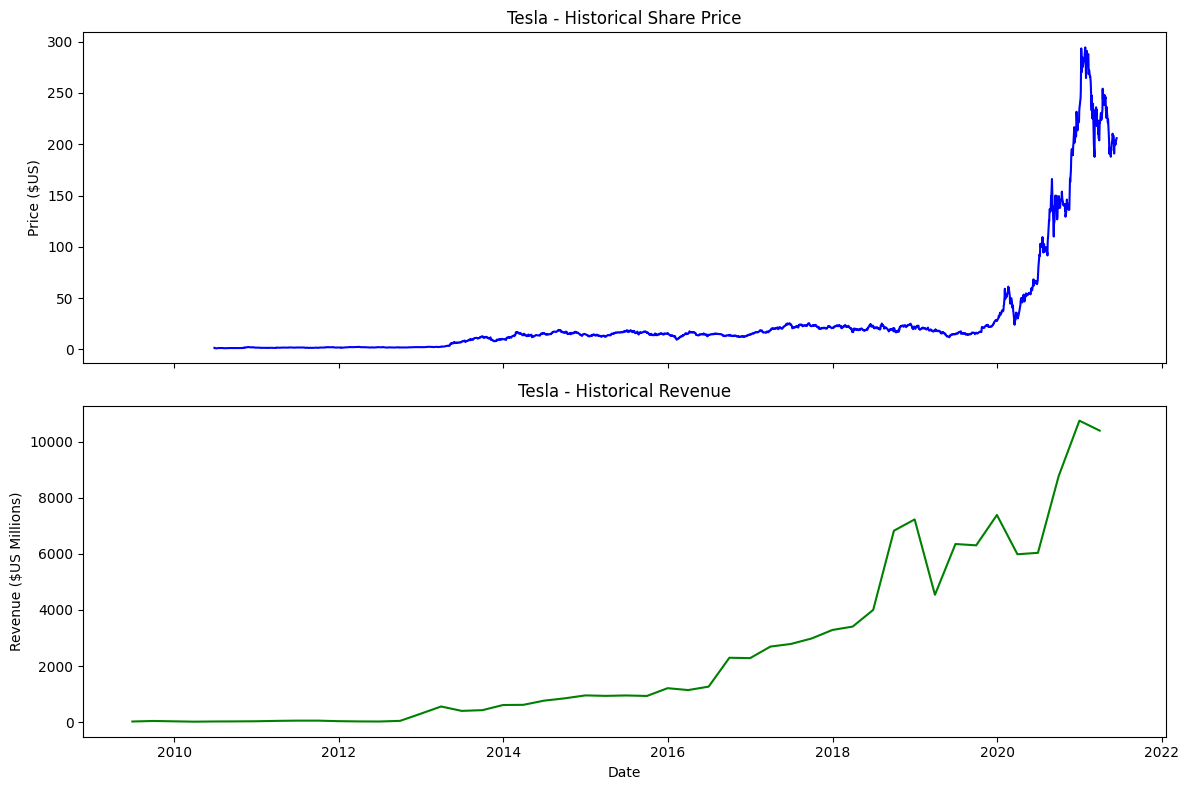

In [9]:
make_graph(tesla_data, tesla_revenue, "Tesla")

<strong>Key Findings : </strong>
- Tesla's revenue increased significantly over time.
- Tesla's stock price also shows strong growth.
- This suggests that Tesla's business growth was reflected in its stock market performance.

**<h2>GameStop Data Collection & Preparation</h2>**

In [10]:
# Extract GameStop Stock Price Data

game_stop = yf.Ticker("GME")
gme_data = game_stop.history(period="max")
gme_data.reset_index(inplace=True)
gme_data.head(5)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712708,1.716074,1.670626,1.683251,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [11]:
# Webscraping to Extract GameStop Revenue Data

html_data_2 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
data_2  = requests.get(html_data_2).text
soup_2 = BeautifulSoup(data_2, 'html.parser')

In [12]:
# GameStop Revenue Data Cleaning

gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])

tbody2 = soup_2.find_all("tbody")[1]
for row in tbody2.find_all("tr"):
    col = row.find_all("td")
    date = col[0].text
    revenue = col[1].text
    gme_revenue = pd.concat([gme_revenue, pd.DataFrame({"Date": [date], "Revenue": [revenue]})],ignore_index=True)

In [13]:
# GameStop Revenue Data Cleaning

gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(',|\$',"",regex=True)
gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]
gme_revenue.tail(5)

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_417/1378471274.py:3: SyntaxWarning: invalid escape sequence '\$'
  gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(',|\$',"",regex=True)


,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


**<h2>GameStop Stock & Revenue Data Analysis</h2>**

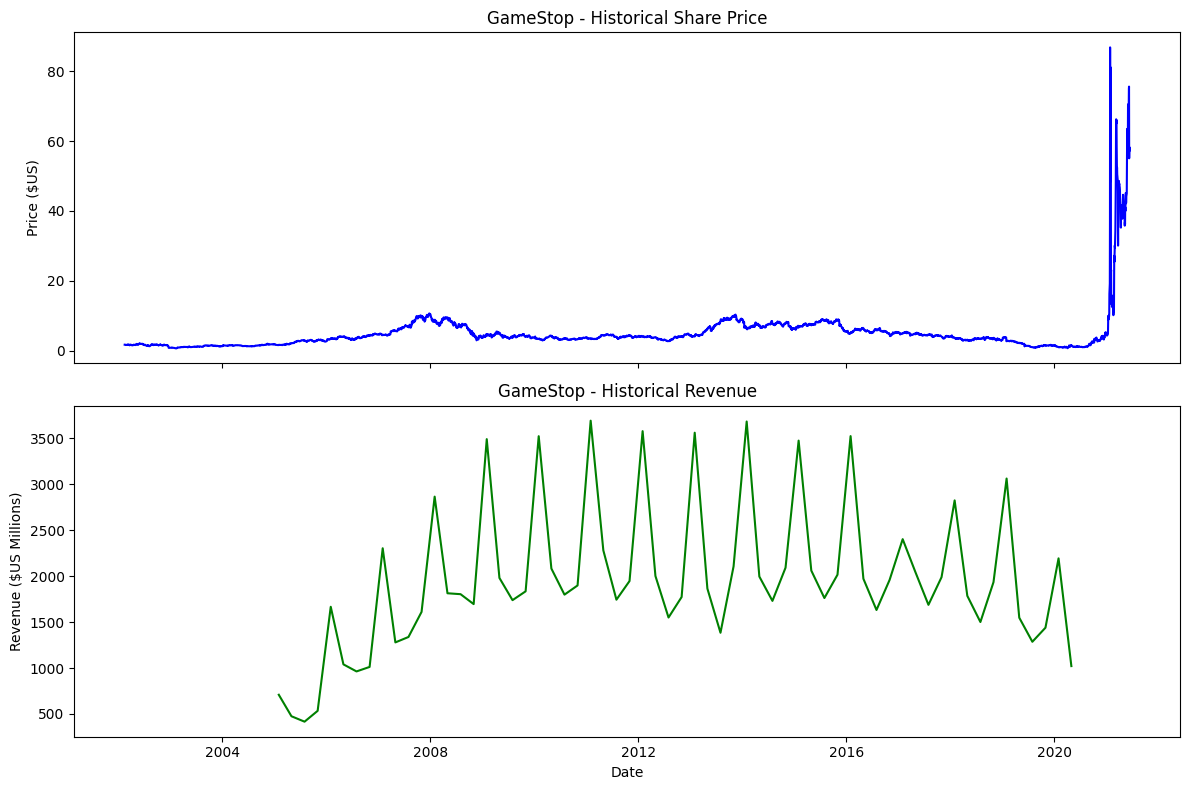

In [14]:
make_graph(gme_data, gme_revenue, 'GameStop')

<strong>Key Findings : </strong>

- GameStop's revenue did not show significant growth over time.
- The increase in stock price was much larger than the increase in revenue. This suggests that the stock price was influenced by factors other than company performance. Investor interest and market trends likely played an important role in driving the stock price higher.

<strong><h2>Insight & Conclusions</h2></strong>

This analysis shows that stock prices do not always move based on company performance alone.

- Tesla is an example where business growth and stock price growth moved in the same direction.
- GameStop is an example where stock prices increased sharply even though revenue did not grow significantly.

Therefore, investors should consider both company performance and market sentiment when evaluating a stock.